#Dataset 1

# Retail Sales Data Analysis

#Importing required python libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#Loading dataset

In [ ]:
df = pd.read_csv('/content/retail_sales_dataset.csv')


In [ ]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
df.shape

(1000, 9)

In [ ]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df['Date']

,Date
0,2023-11-24
1,2023-02-27
2,2023-01-13
3,2023-05-21
4,2023-05-06
...,...
995,2023-05-16
996,2023-11-17
997,2023-10-29
998,2023-12-05


In [ ]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [ ]:
print("Mean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nMode")
print(df.mode().iloc[0])

Mean
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode
Transaction ID                        1
Date                2023-05-16 00:00:00
Customer ID                     CUST001
Gender                           Female
Age                                43.0
Product Category               Clothing
Quantity                            4.0
Price per Unit                     50.0
Total Amount                       50.0
Age Group                         46-60
Name: 0, dtype: object


In [ ]:
df.std(numeric_only=True)

,0
Transaction ID,288.819436
Age,13.681430
Quantity,1.132734
Price per Unit,189.681356
Total Amount,559.997632


#Visualizations

#Time Series Analysis

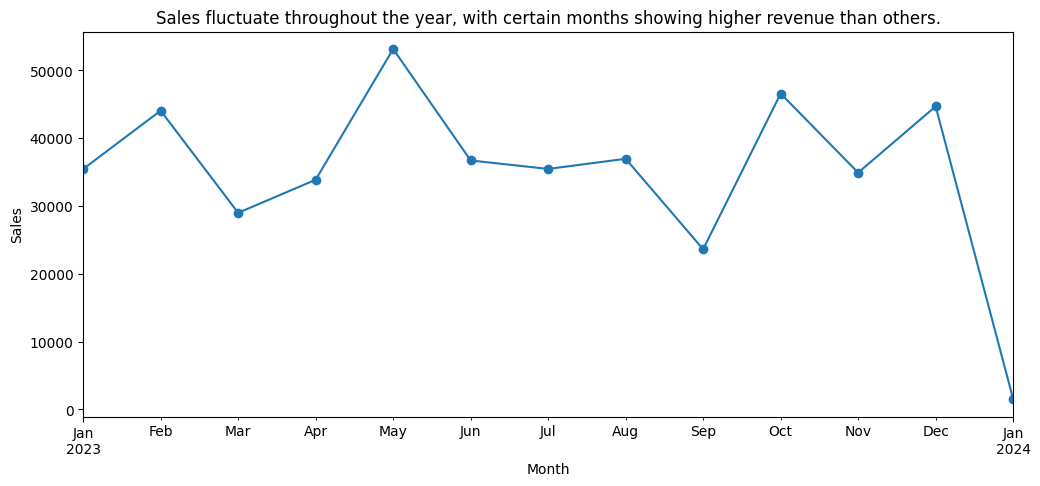

In [ ]:
monthly_sales = df.groupby(
    df['Date'].dt.to_period('M')
)['Total Amount'].sum()

monthly_sales.plot(
    figsize=(12,5),
    marker='o'
)

plt.title("Sales fluctuate throughout the year, with certain months showing higher revenue than others.")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

##Customer Analysis

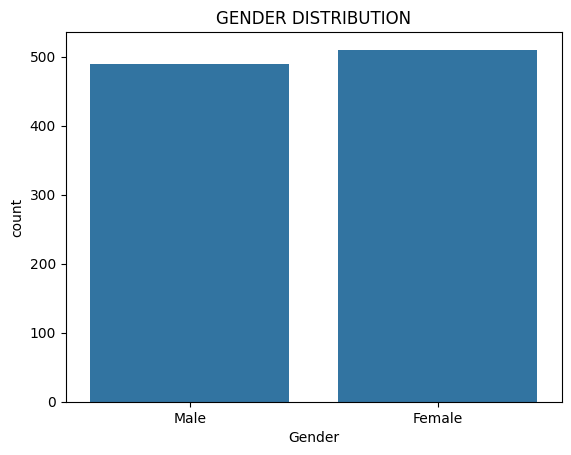

In [ ]:
sns.countplot(x='Gender', data=df)

plt.title("GENDER DISTRIBUTION")
plt.show()

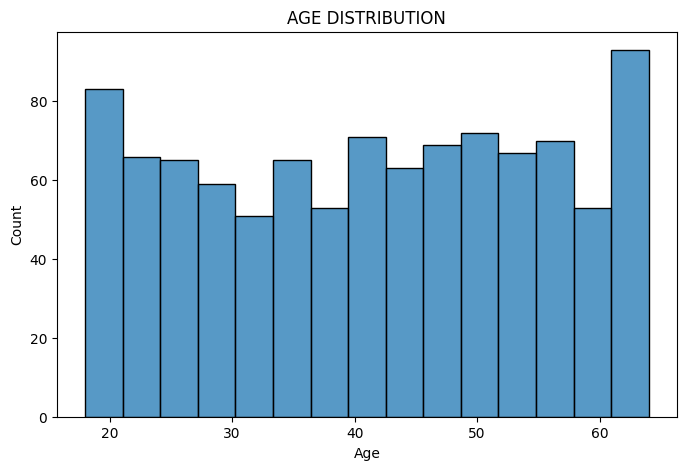

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=15)

plt.title("AGE DISTRIBUTION")
plt.show()

In [ ]:
df.groupby('Gender')['Total Amount'].mean()

,Total Amount
Gender,
Female,456.549020
Male,455.428571


In [ ]:
df.groupby('Gender')['Total Amount'].agg(['sum','mean'])

,sum,mean
Gender,,
Female,232840,456.549020
Male,223160,455.428571


/tmp/ipykernel_1819/1011282448.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df.groupby('Age Group')['Total Amount'].sum()


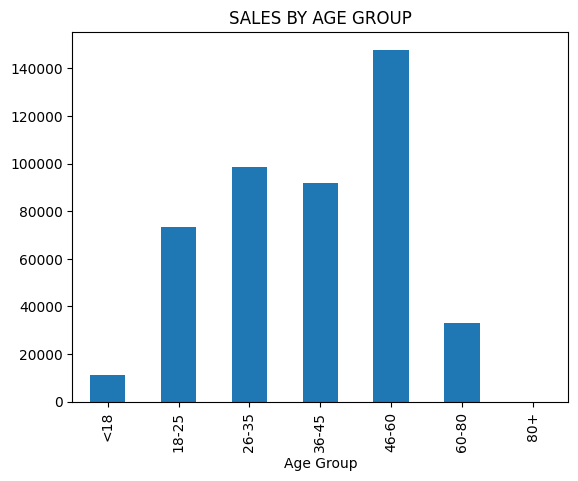

In [ ]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0,18,25,35,45,60,80,100],
    labels=['<18','18-25','26-35','36-45','46-60','60-80','80+']
)

age_sales = df.groupby('Age Group')['Total Amount'].sum()

age_sales.plot(kind='bar')
plt.title('SALES BY AGE GROUP')
plt.show()

/tmp/ipykernel_1819/1099735665.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


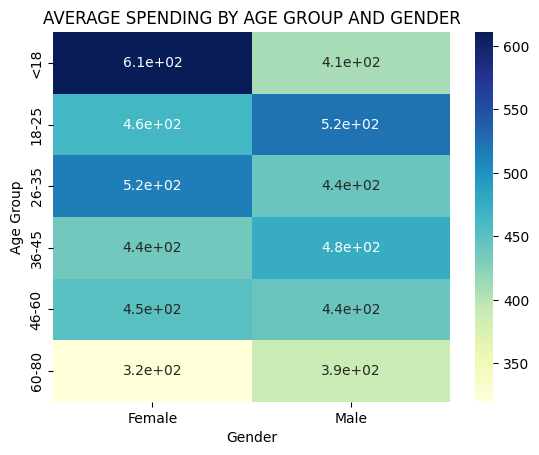

In [ ]:
pivot = pd.pivot_table(
    df,
    values='Total Amount',
    index='Age Group',
    columns='Gender',
    aggfunc='mean'
)

sns.heatmap(
    pivot,
    annot=True,
    cmap='YlGnBu'
)

plt.title('AVERAGE SPENDING BY AGE GROUP AND GENDER')
plt.show()

##Product Analysis

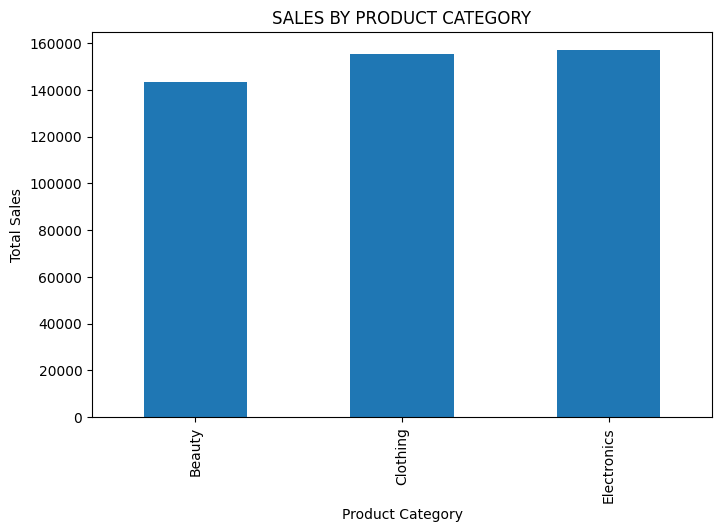

In [ ]:
product_sales = df.groupby(
    'Product Category'
)['Total Amount'].sum()

product_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("SALES BY PRODUCT CATEGORY")
plt.ylabel("Total Sales")
plt.show()

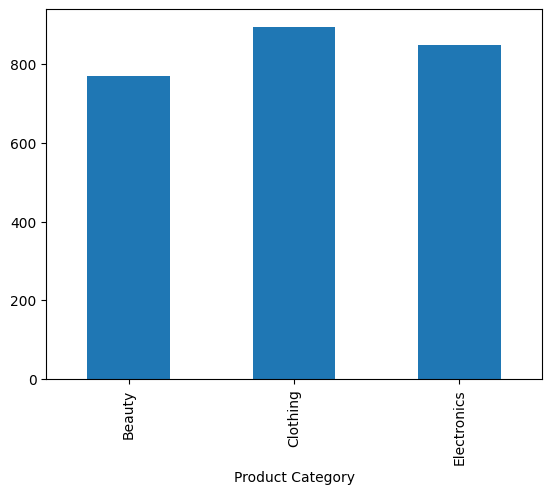

In [ ]:
df.groupby(
    'Product Category'
)['Quantity'].sum().plot(
    kind='bar'
)

plt.show()

In [ ]:
top_customers = df.groupby(
    'Customer ID'
)['Total Amount'].sum().sort_values(
    ascending=False
)

top_customers.head(10)

,Total Amount
Customer ID,
CUST015,2000
CUST412,2000
CUST970,2000
CUST547,2000
CUST281,2000
CUST416,2000
CUST420,2000
CUST927,2000
CUST447,2000


In [ ]:
df['Total Amount'].mean()

np.float64(456.0)

##Correlation Analysis

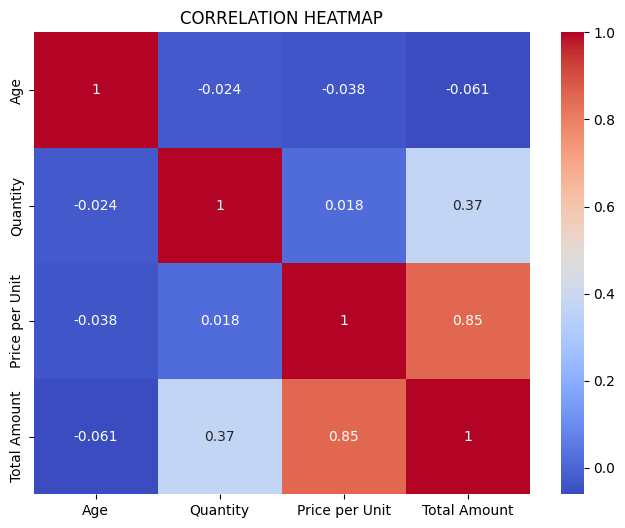

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Age','Quantity',
        'Price per Unit',
        'Total Amount']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("CORRELATION HEATMAP")
plt.show()

# Recommendations

1. Increase inventory and promotional efforts for top-performing product categories to maximize revenue.

2. Target high-spending customer segments with personalized marketing campaigns and special offers.

3. Implement loyalty programs to improve customer retention and encourage repeat purchases.

4. Use monthly sales trends for demand forecasting and inventory planning.

5. Develop demographic-based marketing strategies using customer age and gender insights.

# Dataset 2

##McDonald's Nutrition Facts Data Analysis

##Importing required python libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#loading dataset

In [ ]:
df=pd.read_csv('/content/menu.csv')

In [ ]:
df.head()

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,Breakfast,Egg McMuffin,4.8 oz (136 g),300,120,13.0,20,5.0,25,0.0,...,31,10,4,17,3,17,10,0,25,15
1,Breakfast,Egg White Delight,4.8 oz (135 g),250,70,8.0,12,3.0,15,0.0,...,30,10,4,17,3,18,6,0,25,8
2,Breakfast,Sausage McMuffin,3.9 oz (111 g),370,200,23.0,35,8.0,42,0.0,...,29,10,4,17,2,14,8,0,25,10
3,Breakfast,Sausage McMuffin with Egg,5.7 oz (161 g),450,250,28.0,43,10.0,52,0.0,...,30,10,4,17,2,21,15,0,30,15
4,Breakfast,Sausage McMuffin with Egg Whites,5.7 oz (161 g),400,210,23.0,35,8.0,42,0.0,...,30,10,4,17,2,21,6,0,25,10


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Category                       260 non-null    object 
 1   Item                           260 non-null    object 
 2   Serving Size                   260 non-null    object 
 3   Calories                       260 non-null    int64  
 4   Calories from Fat              260 non-null    int64  
 5   Total Fat                      260 non-null    float64
 6   Total Fat (% Daily Value)      260 non-null    int64  
 7   Saturated Fat                  260 non-null    float64
 8   Saturated Fat (% Daily Value)  260 non-null    int64  
 9   Trans Fat                      260 non-null    float64
 10  Cholesterol                    260 non-null    int64  
 11  Cholesterol (% Daily Value)    260 non-null    int64  
 12  Sodium                         260 non-null    int

In [ ]:
df.isnull().sum()

,0
Category,0
Item,0
Serving Size,0
Calories,0
Calories from Fat,0
Total Fat,0
Total Fat (% Daily Value),0
Saturated Fat,0
Saturated Fat (% Daily Value),0
Trans Fat,0


In [ ]:
df.describe()

,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,Cholesterol,Cholesterol (% Daily Value),Sodium,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
count,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,...,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,368.269231,127.096154,14.165385,21.815385,6.007692,29.965385,0.203846,54.942308,18.392308,495.750000,...,47.346154,15.780769,1.630769,6.530769,29.423077,13.338462,13.426923,8.534615,20.973077,7.734615
std,240.269886,127.875914,14.205998,21.885199,5.321873,26.639209,0.429133,87.269257,29.091653,577.026323,...,28.252232,9.419544,1.567717,6.307057,28.679797,11.426146,24.366381,26.345542,17.019953,8.723263
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,210.000000,20.000000,2.375000,3.750000,1.000000,4.750000,0.000000,5.000000,2.000000,107.500000,...,30.000000,10.000000,0.000000,0.000000,5.750000,4.000000,2.000000,0.000000,6.000000,0.000000
50%,340.000000,100.000000,11.000000,17.000000,5.000000,24.000000,0.000000,35.000000,11.000000,190.000000,...,44.000000,15.000000,1.000000,5.000000,17.500000,12.000000,8.000000,0.000000,20.000000,4.000000
75%,500.000000,200.000000,22.250000,35.000000,10.000000,48.000000,0.000000,65.000000,21.250000,865.000000,...,60.000000,20.000000,3.000000,10.000000,48.000000,19.000000,15.000000,4.000000,30.000000,15.000000
max,1880.000000,1060.000000,118.000000,182.000000,20.000000,102.000000,2.500000,575.000000,192.000000,3600.000000,...,141.000000,47.000000,7.000000,28.000000,128.000000,87.000000,170.000000,240.000000,70.000000,40.000000


In [ ]:
df.mean(numeric_only=True)

,0
Calories,368.269231
Calories from Fat,127.096154
Total Fat,14.165385
Total Fat (% Daily Value),21.815385
Saturated Fat,6.007692
Saturated Fat (% Daily Value),29.965385
Trans Fat,0.203846
Cholesterol,54.942308
Cholesterol (% Daily Value),18.392308
Sodium,495.750000


In [ ]:
df.median(numeric_only=True)

,0
Calories,340.0
Calories from Fat,100.0
Total Fat,11.0
Total Fat (% Daily Value),17.0
Saturated Fat,5.0
Saturated Fat (% Daily Value),24.0
Trans Fat,0.0
Cholesterol,35.0
Cholesterol (% Daily Value),11.0
Sodium,190.0


In [ ]:

df.mode().iloc[0]

,0
Category,Coffee & Tea
Item,1% Low Fat Milk Jug
Serving Size,16 fl oz cup
Calories,0.0
Calories from Fat,0.0
Total Fat,0.0
Total Fat (% Daily Value),0.0
Saturated Fat,0.0
Saturated Fat (% Daily Value),0.0
Trans Fat,0.0


In [ ]:
df.std(numeric_only=True)

,0
Calories,240.269886
Calories from Fat,127.875914
Total Fat,14.205998
Total Fat (% Daily Value),21.885199
Saturated Fat,5.321873
Saturated Fat (% Daily Value),26.639209
Trans Fat,0.429133
Cholesterol,87.269257
Cholesterol (% Daily Value),29.091653
Sodium,577.026323


In [ ]:
df.std(numeric_only=True)

,0
Calories,240.269886
Calories from Fat,127.875914
Total Fat,14.205998
Total Fat (% Daily Value),21.885199
Saturated Fat,5.321873
Saturated Fat (% Daily Value),26.639209
Trans Fat,0.429133
Cholesterol,87.269257
Cholesterol (% Daily Value),29.091653
Sodium,577.026323


##Category Analysis

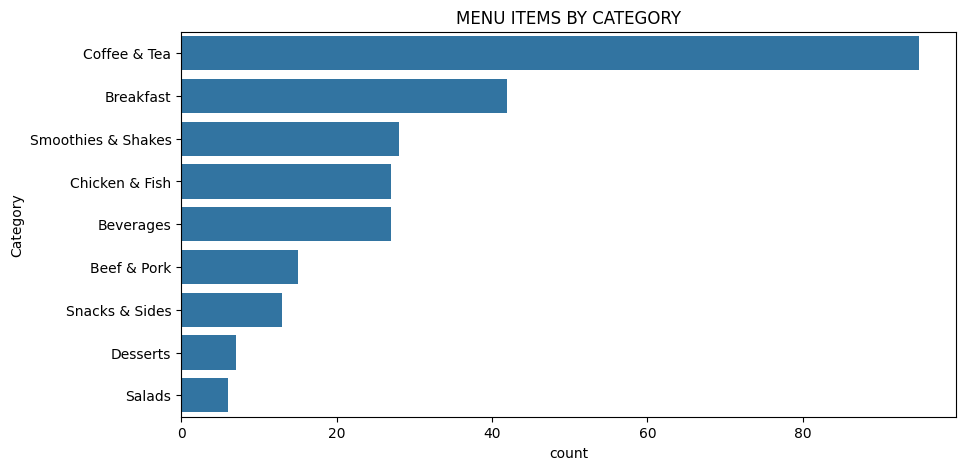

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='Category',
    data=df,
    order=df['Category'].value_counts().index
)

plt.title("MENU ITEMS BY CATEGORY")
plt.show()

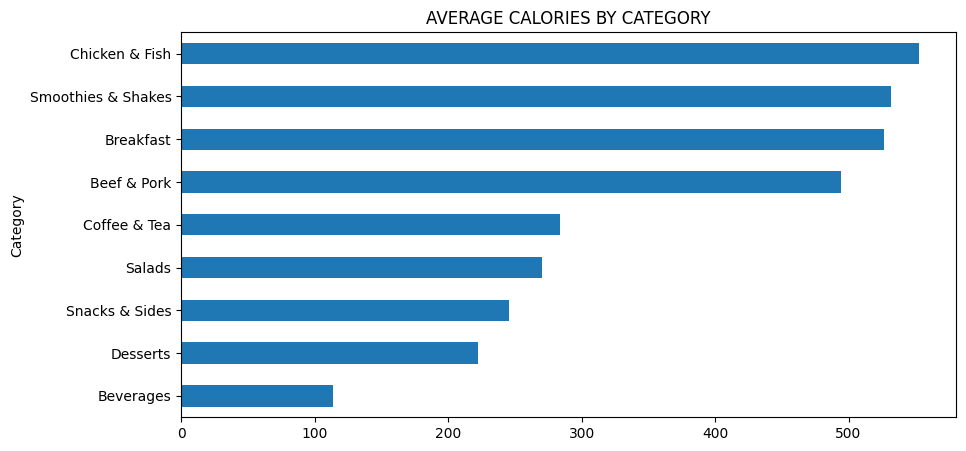

In [ ]:
category_calories = df.groupby(
    'Category'
)['Calories'].mean().sort_values()

category_calories.plot(
    kind='barh',
    figsize=(10,5)
)

plt.title("AVERAGE CALORIES BY CATEGORY")
plt.show()

##Nutrition Analysis

In [ ]:
df.nsmallest(
    10,
    'Calories'
)[['Item','Calories']]

,Item,Calories
114,Diet Coke (Small),0
115,Diet Coke (Medium),0
116,Diet Coke (Large),0
117,Diet Coke (Child),0
122,Diet Dr Pepper (Small),0
123,Diet Dr Pepper (Medium),0
124,Diet Dr Pepper (Large),0
125,Diet Dr Pepper (Child),0
136,Dasani Water Bottle,0
137,Iced Tea (Small),0


In [ ]:
df.nlargest(
    10,
    'Protein'
)[['Item','Protein']]

,Item,Protein
82,Chicken McNuggets (40 piece),87
47,Double Quarter Pounder with Cheese,48
81,Chicken McNuggets (20 piece),44
60,Premium Grilled Chicken Club Sandwich,40
64,Bacon Clubhouse Grilled Chicken Sandwich,40
51,Bacon Clubhouse Burger,39
44,Quarter Pounder with Bacon & Cheese,37
45,Quarter Pounder with Bacon Habanero Ranch,37
31,Big Breakfast with Hotcakes (Regular Biscuit),36
32,Big Breakfast with Hotcakes (Large Biscuit),36


##Correlation Heatmap

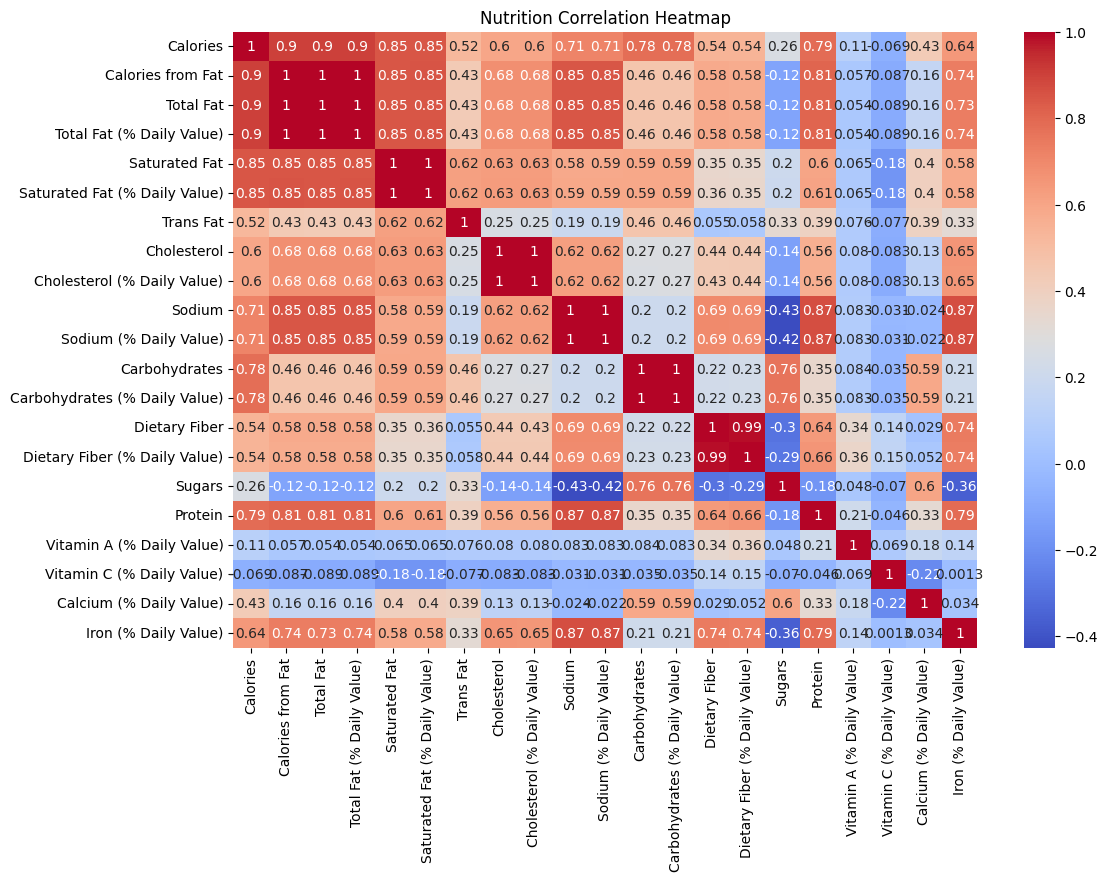

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Nutrition Correlation Heatmap")
plt.show()

##Time Series Challenge

This dataset contains nutritional information about menu items and does not contain any date or time-related attributes. Therefore, time series analysis could not be performed.

##Recommendations

1.Promote lower-calorie menu options to health-conscious customers.

2.Introduce more high-protein and low-fat meal choices.

3.Reduce sodium content in highly processed menu items.

4.Clearly display nutritional information to help customers make informed decisions.

5.Expand healthy menu categories to meet changing consumer preferences.[link text